<a href="https://colab.research.google.com/github/wVks/mipt_speech_technology_25_maksim_fetisov/blob/main/Denoise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

In [90]:
audio_path = "/content/AEG_1934.mp3"
audio_original, sr = sf.read(audio_path)

if len(audio_original.shape) > 1:
    audio_original = np.mean(audio_original, axis=1)

audio_original = audio_original / np.max(np.abs(audio_original))

In [91]:
def add_noise(audio, snr_db=5):
    """Добавление белого шума"""
    signal_power = np.mean(audio ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.randn(len(audio)) * np.sqrt(noise_power)
    noisy_audio = audio + noise
    noisy_audio = noisy_audio / np.max(np.abs(noisy_audio))
    return noisy_audio, noise

audio_noisy, noise = add_noise(audio_original, snr_db=5)

In [92]:
def hz_to_mel(frequency):
    """Преобразование Гц в мел"""
    return 2595 * np.log10(1 + frequency / 700)

def mel_to_hz(mel):
    """Преобразование мел в Гц"""
    return 700 * (10 ** (mel / 2595) - 1)

def compute_mel_spectrogram(audio, sr, n_fft=2048, hop_length=512, n_mels=128, fmax=8000):
    """Вычисление Mel-спектрограммы"""
    N_FFT = n_fft
    HOP_LENGTH = hop_length
    N_MELS = n_mels
    FMIN = 0
    FMAX = fmax

    mel_min = hz_to_mel(FMIN)
    mel_max = hz_to_mel(FMAX)
    mel_points = np.linspace(mel_min, mel_max, N_MELS + 2)
    hz_points = mel_to_hz(mel_points)

    fft_bins = np.floor((N_FFT + 1) * hz_points / sr).astype(int)

    mel_filters = np.zeros((N_MELS, N_FFT // 2 + 1))

    for i in range(N_MELS):
        left = fft_bins[i]
        center = fft_bins[i + 1]
        right = fft_bins[i + 2]

        if left < center:
            mel_filters[i, left:center] = np.linspace(0, 1, center - left)
        if center < right:
            mel_filters[i, center:right] = np.linspace(1, 0, right - center)

    mel_filters = mel_filters / np.maximum(np.sum(mel_filters, axis=1, keepdims=True), 1e-10)

    audio_padded = np.pad(audio, (N_FFT // 2, N_FFT // 2), mode='reflect')
    window = 0.5 * (1 - np.cos(2 * np.pi * np.arange(N_FFT) / (N_FFT - 1)))

    n_frames = 1 + (len(audio_padded) - N_FFT) // HOP_LENGTH
    stft_result = np.zeros((N_FFT // 2 + 1, n_frames), dtype=np.complex128)

    for i in range(n_frames):
        start = i * HOP_LENGTH
        end = start + N_FFT
        frame = audio_padded[start:end] * window
        stft_result[:, i] = np.fft.fft(frame)[:N_FFT // 2 + 1]

    power_spectrogram = np.abs(stft_result) ** 2
    mel_spectrogram = np.dot(mel_filters, power_spectrogram)

    def power_to_db(spectrogram, ref=1.0):
        return 10.0 * np.log10(np.maximum(spectrogram, 1e-10)) - 10.0 * np.log10(np.maximum(ref, 1e-10))

    mel_spectrogram_db = power_to_db(mel_spectrogram)

    return mel_spectrogram_db

In [93]:
def spectral_gate_noise_reduction(audio, sr, n_fft=2048, hop_length=512):
    """Алгоритм шумоподавления Spectral Gating"""
    N_FFT = n_fft
    HOP_LENGTH = hop_length

    audio_padded = np.pad(audio, (N_FFT // 2, N_FFT // 2), mode='reflect')
    window = 0.5 * (1 - np.cos(2 * np.pi * np.arange(N_FFT) / (N_FFT - 1)))

    n_frames = 1 + (len(audio_padded) - N_FFT) // HOP_LENGTH
    indices = np.arange(N_FFT)[None, :] + np.arange(n_frames)[:, None] * HOP_LENGTH

    frames = audio_padded[indices]
    frames_windowed = frames * window

    fft_result = np.fft.fft(frames_windowed, axis=1)[:, :N_FFT // 2 + 1].T
    magnitude = np.abs(fft_result)
    phase = np.angle(fft_result)

    # Оценка шума
    noise_frames = min(20, n_frames // 4)
    noise_profile = np.median(magnitude[:, :noise_frames], axis=1, keepdims=True)

    snr_per_bin = magnitude / (noise_profile + 1e-10)

    mask = np.ones_like(snr_per_bin) * 0.2
    transition_mask = (snr_per_bin >= 1.0) & (snr_per_bin <= 2.0)
    good_mask = snr_per_bin > 2.0

    mask[transition_mask] = 0.2 + 0.8 * (snr_per_bin[transition_mask] - 1.0)
    mask[good_mask] = 1.0

    # Временное сглаживание
    kernel = np.ones((1, 7)) / 7  # Окно 7 кадров
    mask_smoothed_time = np.apply_along_axis(
        lambda x: np.convolve(x, kernel[0], mode='same'),
        axis=1,
        arr=mask
    )

    # Частотное сглаживание
    kernel_freq = np.ones((5, 1)) / 5  # Окно 5 частотных бинов
    mask_smoothed = np.apply_along_axis(
        lambda x: np.convolve(x, kernel_freq[:, 0], mode='same'),
        axis=0,
        arr=mask_smoothed_time
    )

    mask_final = np.maximum(mask_smoothed, 0.1)
    magnitude_clean = magnitude * mask_final

    complex_spectrum = magnitude_clean * np.exp(1j * phase)

    full_spectrum_top = complex_spectrum.T
    full_spectrum_bottom = np.conj(complex_spectrum[-2:0:-1, :]).T

    full_spectrum = np.zeros((n_frames, N_FFT), dtype=np.complex128)
    full_spectrum[:, :N_FFT // 2 + 1] = full_spectrum_top
    full_spectrum[:, N_FFT // 2 + 1:] = full_spectrum_bottom

    # Обратное FFT
    frames_clean = np.fft.ifft(full_spectrum, axis=1).real * window

    audio_clean = np.zeros(len(audio_padded))
    for i in range(n_frames):
        start = i * HOP_LENGTH
        end = start + N_FFT
        audio_clean[start:end] += frames_clean[i, :]

    audio_clean = audio_clean[N_FFT // 2:-N_FFT // 2]

    if len(audio_clean) > len(audio):
        audio_clean = audio_clean[:len(audio)]

    original_energy = np.sqrt(np.mean(audio**2))
    cleaned_energy = np.sqrt(np.mean(audio_clean**2))

    if cleaned_energy > 0:
        audio_clean = audio_clean * (original_energy / cleaned_energy)

    max_val = np.max(np.abs(audio_clean))
    if max_val > 0:
        audio_clean = audio_clean / max_val

    return audio_clean

audio_processed = spectral_gate_noise_reduction(audio_noisy, sr)

min_len = min(len(audio_original), len(audio_noisy), len(audio_processed))
audio_original = audio_original[:min_len]
audio_noisy = audio_noisy[:min_len]
audio_processed = audio_processed[:min_len]

In [94]:
mel_spec_original = compute_mel_spectrogram(audio_original, sr)
mel_spec_noisy = compute_mel_spectrogram(audio_noisy, sr)
mel_spec_processed = compute_mel_spectrogram(audio_processed, sr)

In [95]:
def compute_metrics(clean_audio, test_audio):
    """Вычисление метрик"""
    min_len = min(len(clean_audio), len(test_audio))
    clean = clean_audio[:min_len]
    test = test_audio[:min_len]

    # SNR
    noise = test - clean
    signal_power = np.mean(clean**2)
    noise_power = np.mean(noise**2)
    snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')

    # SI-SDR
    alpha = np.dot(clean, test) / (np.dot(clean, clean) + 1e-10)
    target = alpha * clean
    error = test - target
    s_target = np.sum(target**2)
    s_error = np.sum(error**2)
    sisdr = 10 * np.log10(s_target / s_error) if s_error > 0 else float('inf')

    return {
        'SNR': snr,
        'SI-SDR': sisdr
    }

metrics_noisy = compute_metrics(audio_original, audio_noisy)
metrics_processed = compute_metrics(audio_original, audio_processed)

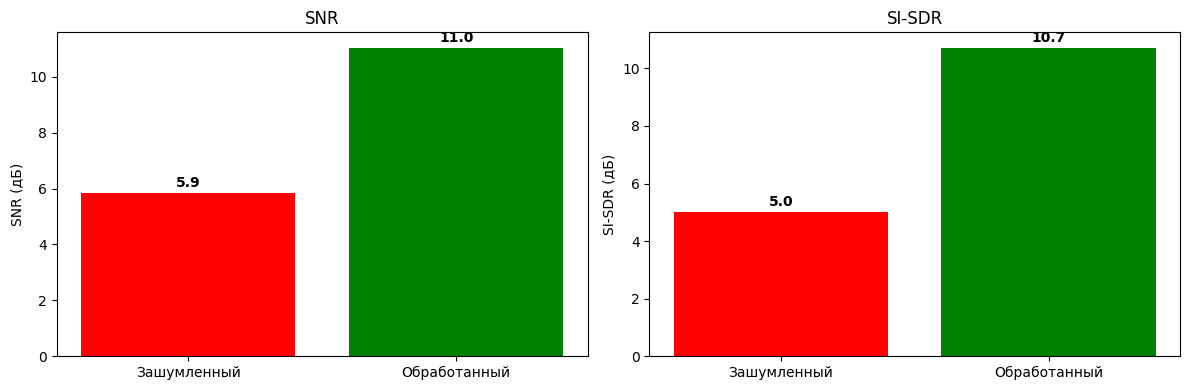

In [96]:
plt.figure(figsize=(12, 4))

algorithms = ['Зашумленный', 'Обработанный']
colors = ['red', 'green']

snr_values = [metrics_noisy['SNR'], metrics_processed['SNR']]
si_sdr_values = [metrics_noisy['SI-SDR'], metrics_processed['SI-SDR']]

# График SNR
plt.subplot(1, 2, 1)
bars = plt.bar(range(len(algorithms)), snr_values, color=colors)
plt.title('SNR')
plt.ylabel('SNR (дБ)')
plt.xticks(range(len(algorithms)), algorithms, rotation=0, ha='center')
for bar, value in zip(bars, snr_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

# График SI-SDR
plt.subplot(1, 2, 2)
bars = plt.bar(range(len(algorithms)), si_sdr_values, color=colors)
plt.title('SI-SDR')
plt.ylabel('SI-SDR (дБ)')
plt.xticks(range(len(algorithms)), algorithms, rotation=0, ha='center')
for bar, value in zip(bars, si_sdr_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

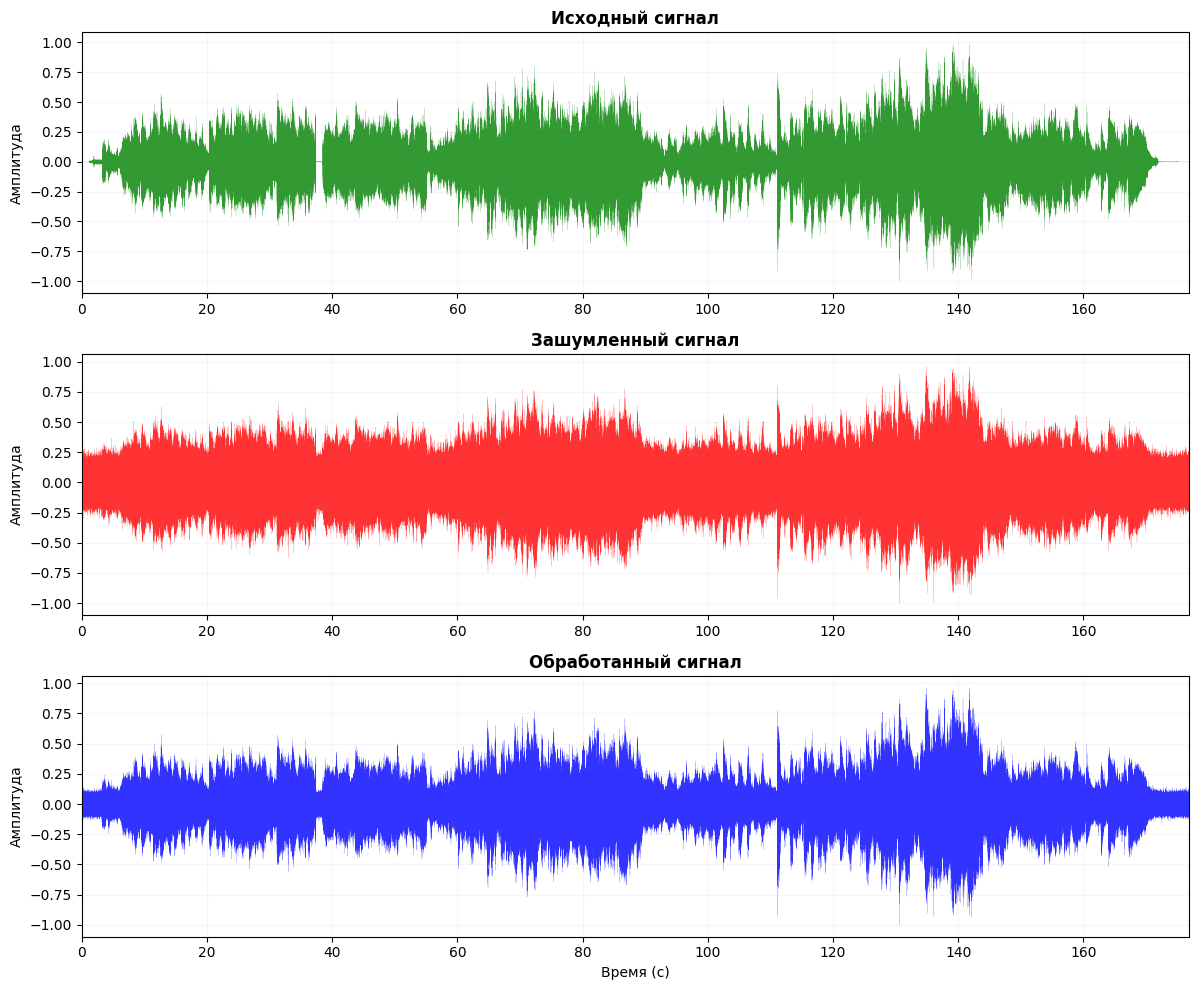

In [97]:
fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10))

time_full = np.arange(len(audio_original)) / sr

axes1[0].plot(time_full, audio_original, 'g-', linewidth=0.1, alpha=0.8)
axes1[0].set_title('Исходный сигнал', fontweight='bold')
axes1[0].set_ylabel('Амплитуда')
axes1[0].grid(True, alpha=0.1)
axes1[0].set_xlim([0, time_full[-1]])

axes1[1].plot(time_full, audio_noisy, 'r-', linewidth=0.1, alpha=0.8)
axes1[1].set_title('Зашумленный сигнал', fontweight='bold')
axes1[1].set_ylabel('Амплитуда')
axes1[1].grid(True, alpha=0.1)
axes1[1].set_xlim([0, time_full[-1]])

axes1[2].plot(time_full, audio_processed, 'b-', linewidth=0.1, alpha=0.8)
axes1[2].set_title('Обработанный сигнал', fontweight='bold')
axes1[2].set_xlabel('Время (с)')
axes1[2].set_ylabel('Амплитуда')
axes1[2].grid(True, alpha=0.1)
axes1[2].set_xlim([0, time_full[-1]])

plt.tight_layout()
plt.show()

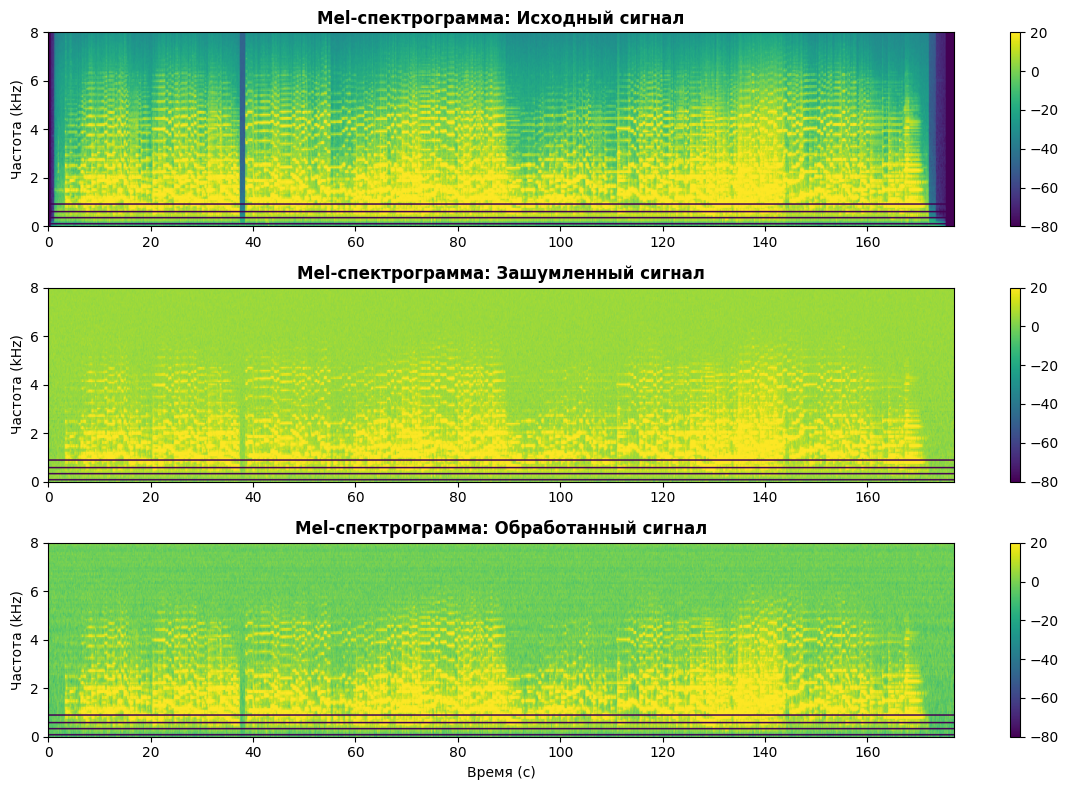

In [98]:
fig2, axes2 = plt.subplots(3, 1, figsize=(12, 8))

time_axis_full = np.arange(mel_spec_original.shape[1]) * 512 / sr
freq_axis_full = np.linspace(0, 8, mel_spec_original.shape[0])

im1 = axes2[0].imshow(mel_spec_original, aspect='auto', origin='lower',
                     extent=[time_axis_full[0], time_axis_full[-1],
                             freq_axis_full[0], freq_axis_full[-1]],
                     cmap='viridis', vmin=-80, vmax=20)
axes2[0].set_title('Mel-спектрограмма: Исходный сигнал', fontweight='bold')
axes2[0].set_ylabel('Частота (kHz)')
plt.colorbar(im1, ax=axes2[0])

im2 = axes2[1].imshow(mel_spec_noisy, aspect='auto', origin='lower',
                     extent=[time_axis_full[0], time_axis_full[-1],
                             freq_axis_full[0], freq_axis_full[-1]],
                     cmap='viridis', vmin=-80, vmax=20)
axes2[1].set_title('Mel-спектрограмма: Зашумленный сигнал', fontweight='bold')
axes2[1].set_ylabel('Частота (kHz)')
plt.colorbar(im2, ax=axes2[1])

im3 = axes2[2].imshow(mel_spec_processed, aspect='auto', origin='lower',
                     extent=[time_axis_full[0], time_axis_full[-1],
                             freq_axis_full[0], freq_axis_full[-1]],
                     cmap='viridis', vmin=-80, vmax=20)
axes2[2].set_title('Mel-спектрограмма: Обработанный сигнал', fontweight='bold')
axes2[2].set_xlabel('Время (с)')
axes2[2].set_ylabel('Частота (kHz)')
plt.colorbar(im3, ax=axes2[2])

plt.tight_layout()
plt.show()

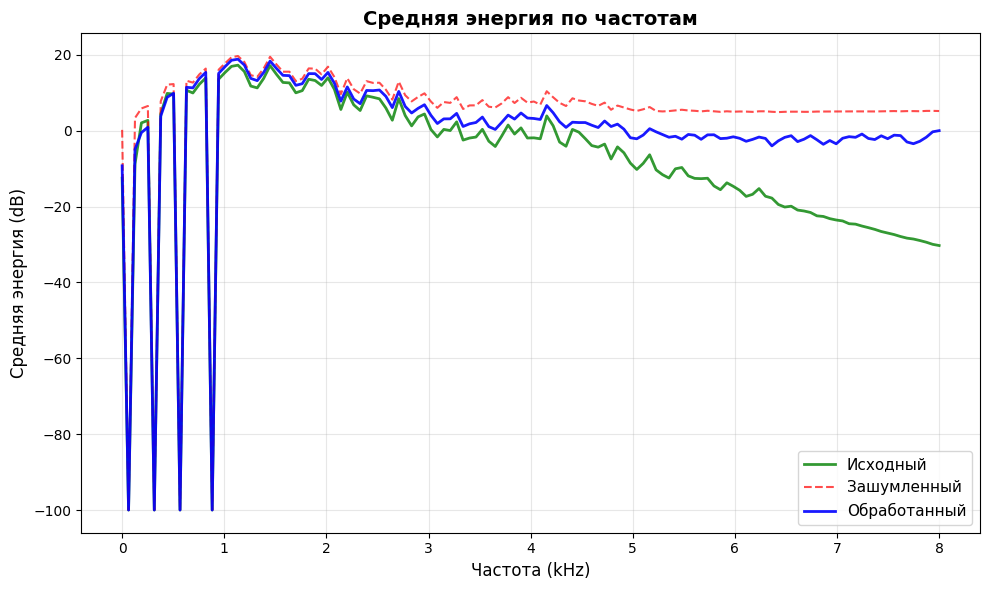

In [105]:
fig4, ax = plt.subplots(figsize=(10, 6))

mean_energy_original = np.mean(mel_spec_original, axis=1)
mean_energy_noisy = np.mean(mel_spec_noisy, axis=1)
mean_energy_processed = np.mean(mel_spec_processed, axis=1)

ax.plot(freq_axis_full, mean_energy_original, 'g-', label='Исходный', linewidth=2, alpha=0.8)
ax.plot(freq_axis_full, mean_energy_noisy, 'r--', label='Зашумленный', linewidth=1.5, alpha=0.7)
ax.plot(freq_axis_full, mean_energy_processed, 'b-', label='Обработанный', linewidth=2, alpha=0.9)

ax.set_xlabel('Частота (kHz)', fontsize=12)
ax.set_ylabel('Средняя энергия (dB)', fontsize=12)
ax.set_title('Средняя энергия по частотам', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()